# A Recommender-Focused EDA
---

**Goal.** This is not a generic data audit. Every chart in this notebook drives toward one
question: **given a movie (or a person), can we surface the other movies its fans also agree
on?** That intersection logic *is* the recommender.

**Strategy.**
1. Define the **love graph** — every (user, film) rating ≥ 4 ★ is an edge.
2. Compute **movie ↔ movie co-love** to expose intersections like *"fans of X also loved Y."*
3. Compute **user ↔ user similarity** to expose **tastemates** — people whose love sets
   overlap a lot with yours.
4. Demonstrate the **pair recommender** — given two users, return the films their tastemate
   cohort agrees on but neither has watched yet.


## 1 · Setup

In [1]:
import warnings, itertools, textwrap
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

# Letterboxd-inspired dark palette
LB_GREEN, LB_BLUE, LB_ORANGE = "#00C030", "#40BCF4", "#FF8000"
LB_BG, LB_PANEL, LB_GRID = "#14181C", "#1C2128", "#2C3440"
LB_TEXT, LB_MUTED = "#E8E8E8", "#9AB"

mpl.rcParams.update({
    "figure.facecolor": LB_BG, "axes.facecolor": LB_PANEL,
    "savefig.facecolor": LB_BG, "axes.edgecolor": LB_GRID,
    "axes.labelcolor": LB_TEXT, "axes.titlecolor": LB_TEXT,
    "axes.titleweight": "bold", "axes.titlesize": 13,
    "xtick.color": LB_TEXT, "ytick.color": LB_TEXT,
    "text.color": LB_TEXT, "grid.color": LB_GRID,
    "grid.linestyle": "--", "grid.alpha": 0.3, "axes.grid": True,
    "axes.spines.top": False, "axes.spines.right": False,
    "legend.facecolor": LB_PANEL, "legend.edgecolor": LB_GRID,
    "legend.labelcolor": LB_TEXT, "figure.dpi": 110,
})
sns.set_palette([LB_GREEN, LB_BLUE, LB_ORANGE])
print("✓ ready")


✓ ready


## 2 · Load & initial audit

We pull in the raw ratings file and report what we have *before* touching anything.


In [2]:
raw = pd.read_csv("user_ratings_enriched2.csv")
print(f"Raw rows           : {len(raw):,}")
print(f"Raw users          : {raw['username'].nunique():,}")
print(f"Raw films          : {raw['proper_title'].nunique():,}")
print(f"Missing tmdb_id    : {raw['tmdb_id'].isna().sum():,}  ({raw['tmdb_id'].isna().mean()*100:.1f}%)")
print(f"Missing genre_1    : {raw['genre_1'].isna().sum():,}  ({raw['genre_1'].isna().mean()*100:.1f}%)")


Raw rows           : 502,749
Raw users          : 241
Raw films          : 51,212
Missing tmdb_id    : 14,396  (2.9%)
Missing genre_1    : 18,591  (3.7%)


## 3 · Cleaning — keeping signal, dropping noise

A recommender that learns from one-off ratings will hallucinate connections that don't exist.
We apply three filters, in order, and report the impact at each step.

| Filter | Rationale |
|---|---|
| Drop rows missing `tmdb_id` / title | Without TMDB enrichment, no genre signal — exclude |
| Deduplicate `(user, film)` | Multiple log-entries inflate similarity falsely |
| **Drop films with < 3 ratings** | Most films have 1–2 ratings; they're noise to a co-occurrence model |
| **Drop users with < 50 ratings** | Sparse users contribute almost nothing to similarity matrices |


                          ratings  users  films  Δ ratings  Δ films  Δ users
raw                        502749    241  51212          0        0        0
after NA + dedup           488353    241  51212     -14396        0        0
after films ≥ 3 ratings    450024    240  19991     -38329   -31221       -1
after users ≥ 50 ratings   450023    239  19991         -1        0       -1


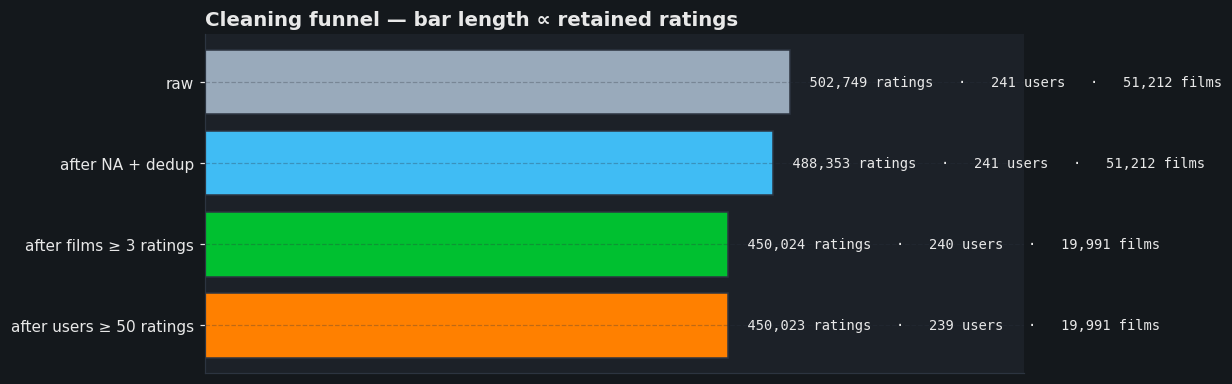

In [3]:
# step 1: drop NA + dedup 
df = raw.dropna(subset=["tmdb_id", "proper_title"]).drop_duplicates(["username", "film_slug"]).copy()
df["tmdb_id"] = df["tmdb_id"].astype("int64")
step1 = (len(df), df["username"].nunique(), df["proper_title"].nunique())

# step 2: drop films with < MIN_FILM ratings 
MIN_FILM = 3
film_n   = df.groupby("proper_title").size()
keep_f   = film_n[film_n >= MIN_FILM].index
df       = df[df["proper_title"].isin(keep_f)]
step2    = (len(df), df["username"].nunique(), df["proper_title"].nunique())

# step 3: drop users with < MIN_USER ratings
MIN_USER = 50
user_n   = df.groupby("username").size()
keep_u   = user_n[user_n >= MIN_USER].index
df       = df[df["username"].isin(keep_u)]
step3    = (len(df), df["username"].nunique(), df["proper_title"].nunique())

# Report
report = pd.DataFrame(
    [(len(raw), raw["username"].nunique(), raw["proper_title"].nunique()),
     step1, step2, step3],
    columns=["ratings", "users", "films"],
    index=["raw", "after NA + dedup", f"after films ≥ {MIN_FILM} ratings",
           f"after users ≥ {MIN_USER} ratings"],
)
report["Δ ratings"] = report["ratings"].diff().fillna(0).astype(int)
report["Δ films"]   = report["films"].diff().fillna(0).astype(int)
report["Δ users"]   = report["users"].diff().fillna(0).astype(int)
print(report)

# Visualise drop impact
fig, ax = plt.subplots(figsize=(11, 3.6))
labels = list(report.index)
y = np.arange(len(labels))[::-1]
norm = report["ratings"] / report["ratings"].iloc[0]
bars = ax.barh(y, norm, color=[LB_MUTED, LB_BLUE, LB_GREEN, LB_ORANGE],
               edgecolor=LB_GRID)
for bar, idx in zip(bars, labels):
    r = report.loc[idx]
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f"{r['ratings']:>9,} ratings   ·   {r['users']:>3} users   ·   {r['films']:>6,} films",
            va="center", fontsize=9, color=LB_TEXT, family="monospace")
ax.set_yticks(y); ax.set_yticklabels(labels, fontsize=10)
ax.set_xlim(0, 1.4); ax.set_xticks([])
ax.set_title("Cleaning funnel — bar length ∝ retained ratings", loc="left")
plt.tight_layout(); plt.show()


**What we keep.** The film-level filter wipes out the long-tail of one-off entries
(roughly half the *films* but only a few percent of *ratings*). The user-level filter is
gentle — almost every user already has well above 50 ratings. Net effect: a much
denser matrix to feed into the recommender.


## 4 · Defining "love"

A **love event** is any rating ≥ 4 ★. This is the binary signal the recommender consumes —
*"did this person's evening turn out well?"* Sticking to the 4-star floor weeds out polite 3 ★s.


In [4]:
LOVE_T = 4.0
df["loved"] = df["rating"] >= LOVE_T
loves = df[df["loved"]].copy()

n_users = df["username"].nunique()
n_films = df["proper_title"].nunique()

print(f"{len(df):>10,}  cleaned ratings")
print(f"{len(loves):>10,}  love events  (≥ {LOVE_T} ★)")
print(f"{n_users:>10,}  users")
print(f"{n_films:>10,}  films")
print(f"{len(loves)/len(df)*100:>10.1f}%  of ratings are loves")


   450,023  cleaned ratings
   170,647  love events  (≥ 4.0 ★)
       239  users
    19,991  films
      37.9%  of ratings are loves


## 5 · The shape of love — *whom do most people love?*

Two views, side by side. Left: films most people love (raw count). Right: films with the
highest **love conversion** — share of viewers who loved it. A high-conversion film with 100
viewers is more useful to the recommender than a polarising blockbuster with 300.


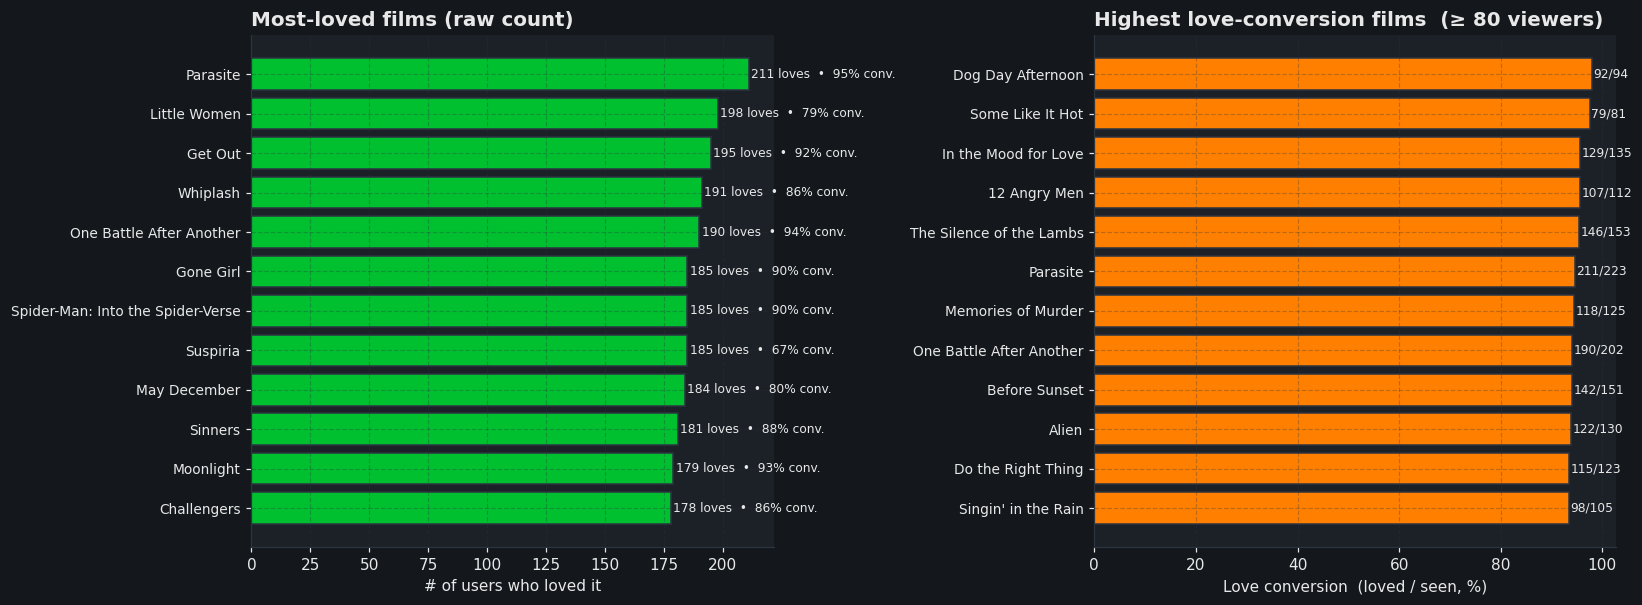

In [5]:
love_count = loves.groupby("proper_title").size()
seen_count = df.groupby("proper_title").size()
film_stats = pd.DataFrame({"loved": love_count, "seen": seen_count}).fillna(0)
film_stats["conversion"] = film_stats["loved"] / film_stats["seen"]

top_loved = film_stats.nlargest(12, "loved")
hi_conv   = film_stats[film_stats["seen"] >= 80].nlargest(12, "conversion")

fig, axes = plt.subplots(1, 2, figsize=(15, 5.6))

ax = axes[0]
y = np.arange(len(top_loved))[::-1]
ax.barh(y, top_loved["loved"], color=LB_GREEN, edgecolor=LB_GRID)
ax.set_yticks(y); ax.set_yticklabels([t[:34] for t in top_loved.index], fontsize=9)
for i, (idx, row) in enumerate(top_loved.iterrows()):
    ax.text(row["loved"]+1, y[i], f"{int(row['loved'])} loves  •  {row['conversion']*100:.0f}% conv.",
            va="center", color=LB_TEXT, fontsize=8)
ax.set_xlabel("# of users who loved it")
ax.set_title("Most-loved films (raw count)", loc="left")

ax = axes[1]
y = np.arange(len(hi_conv))[::-1]
ax.barh(y, hi_conv["conversion"]*100, color=LB_ORANGE, edgecolor=LB_GRID)
ax.set_yticks(y); ax.set_yticklabels([t[:34] for t in hi_conv.index], fontsize=9)
for i, (idx, row) in enumerate(hi_conv.iterrows()):
    ax.text(row["conversion"]*100+0.3, y[i], f"{int(row['loved'])}/{int(row['seen'])}",
            va="center", color=LB_TEXT, fontsize=8)
ax.set_xlabel("Love conversion  (loved / seen, %)")
ax.set_title("Highest love-conversion films  (≥ 80 viewers)", loc="left")

plt.tight_layout(); plt.show()


## 6 · The Genre Atlas — *what kinds of films get loved?*

Two genre-level questions before we zoom into individual films:

1. **Which genres convert ratings into loves the most?** Audiences treat genres very differently — Documentary at ~45% love conversion vs Horror at ~30%.
2. **Which genres co-travel in users' loves?** If users who love a lot of Action also love a lot of Adventure, those two are recommender-substitutes when one signal is missing.

We measure (2) as **Pearson correlation** of per-user genre love-counts. Two genres with a high correlation are loved by the same people in the same proportions.

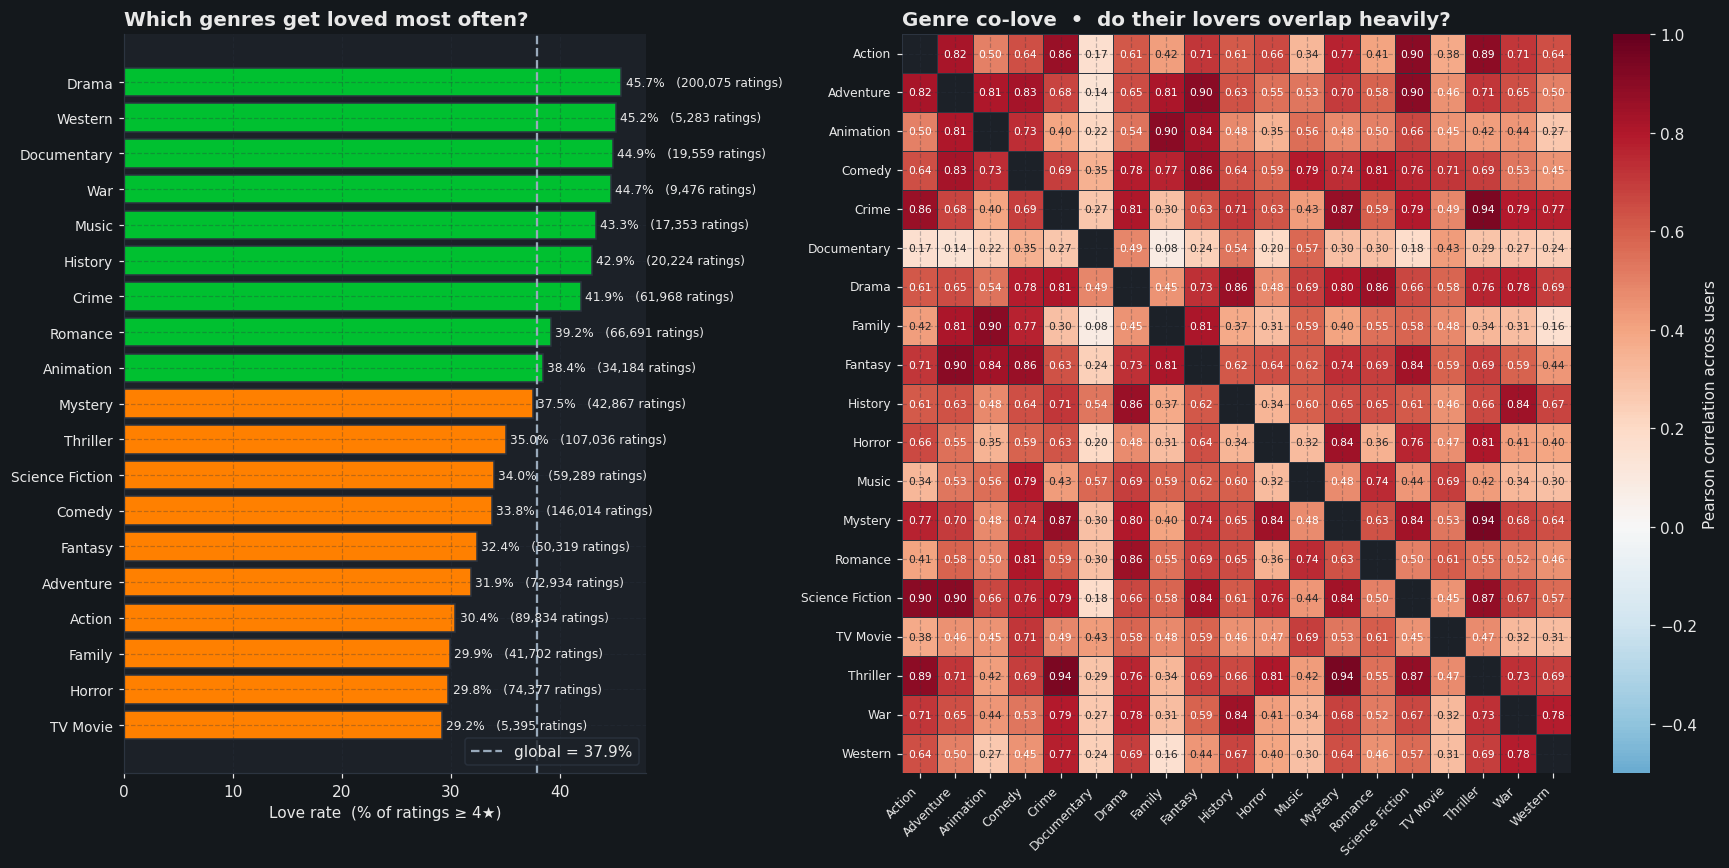

In [ ]:
# Genre Atlas — love rate per genre + genre co-love heatmap ===
gcols = [f"genre_{i}" for i in range(1, 6)]
gen_long = (df.melt(id_vars=["username", "proper_title", "rating", "loved"],
                    value_vars=gcols, var_name="slot", value_name="genre")
              .dropna(subset=["genre"]))

# per-genre love stats
gstats = (gen_long.groupby("genre")
                   .agg(n=("rating", "size"), love_rate=("loved", "mean"))
                   .sort_values("love_rate", ascending=False))

# Genre × genre Pearson correlation across users (per-genre love counts)
ug_count = (gen_long[gen_long["loved"]]
            .groupby(["username", "genre"]).size()
            .unstack(fill_value=0))
genre_corr = ug_count.corr()
gens = list(genre_corr.index)
J = genre_corr.values.copy()
np.fill_diagonal(J, np.nan)

fig, axes = plt.subplots(1, 2, figsize=(16, 8),
                         gridspec_kw={"width_ratios": [1, 1.6]})

# (a) love rate per genre
ax = axes[0]
y = np.arange(len(gstats))[::-1]
global_lr = df["loved"].mean()
colors = [LB_GREEN if r > global_lr else LB_ORANGE for r in gstats["love_rate"]]
ax.barh(y, gstats["love_rate"]*100, color=colors, edgecolor=LB_GRID)
ax.axvline(global_lr*100, ls="--", color=LB_MUTED, label=f"global = {global_lr*100:.1f}%")
ax.set_yticks(y); ax.set_yticklabels(gstats.index, fontsize=9)
for i, (g, row) in enumerate(gstats.iterrows()):
    ax.text(row["love_rate"]*100+0.4, y[i],
            f"{row['love_rate']*100:.1f}%   ({int(row['n']):,} ratings)",
            va="center", color=LB_TEXT, fontsize=8)
ax.set_xlabel("Love rate  (% of ratings ≥ 4★)")
ax.set_title("Which genres get loved most often?", loc="left")
ax.legend(loc="lower right")

# (b) genre co-love correlation heatmap
ax = axes[1]
sns.heatmap(J, xticklabels=gens, yticklabels=gens,
            cmap="RdBu_r", center=0, vmin=-0.5, vmax=1,
            linewidths=0.4, linecolor=LB_GRID,
            cbar_kws={"label": "Pearson correlation across users"}, ax=ax,
            mask=np.isnan(J), annot=True, fmt=".2f", annot_kws={"size": 7})
ax.set_title("Genre co-love  •  do their lovers overlap heavily?", loc="left")
plt.xticks(rotation=45, ha="right", fontsize=8); plt.yticks(fontsize=8)
plt.tight_layout(); plt.show()

Two recommender signals fall out of this single view. First, the love-rate bars are a *pure prior* — Drama, Western, Documentary, and War sit ~8–10 points above the global love rate, meaning a recommendation in those genres is statistically safer than one in Horror or Family before we know anything about the user. Second, the correlation block on the right exposes the **substitute pairs** the recommender will lean on when data is thin: Action↔Adventure (r ≈ 0.85), History↔War, and Crime↔Thriller cluster together, while Drama and Action sit on opposite ends of the same latent axis — the *prestige vs. spectacle* axis the platform's audience implicitly votes along. When a new user has only logged Action films, the model can confidently extend into Adventure; it should be much more cautious extending into Drama.

## 7 · User Genre Fingerprints

Every user has a personal *genre cocktail* — the share of their loves that fall into each genre. We pick **four contrasting users** (each is the platform's biggest fan of a focal genre) and overlay their fingerprints as polar plots. The shape difference makes the recommender's job vivid: **tastemate-matching is essentially shape-matching in this genre space.**

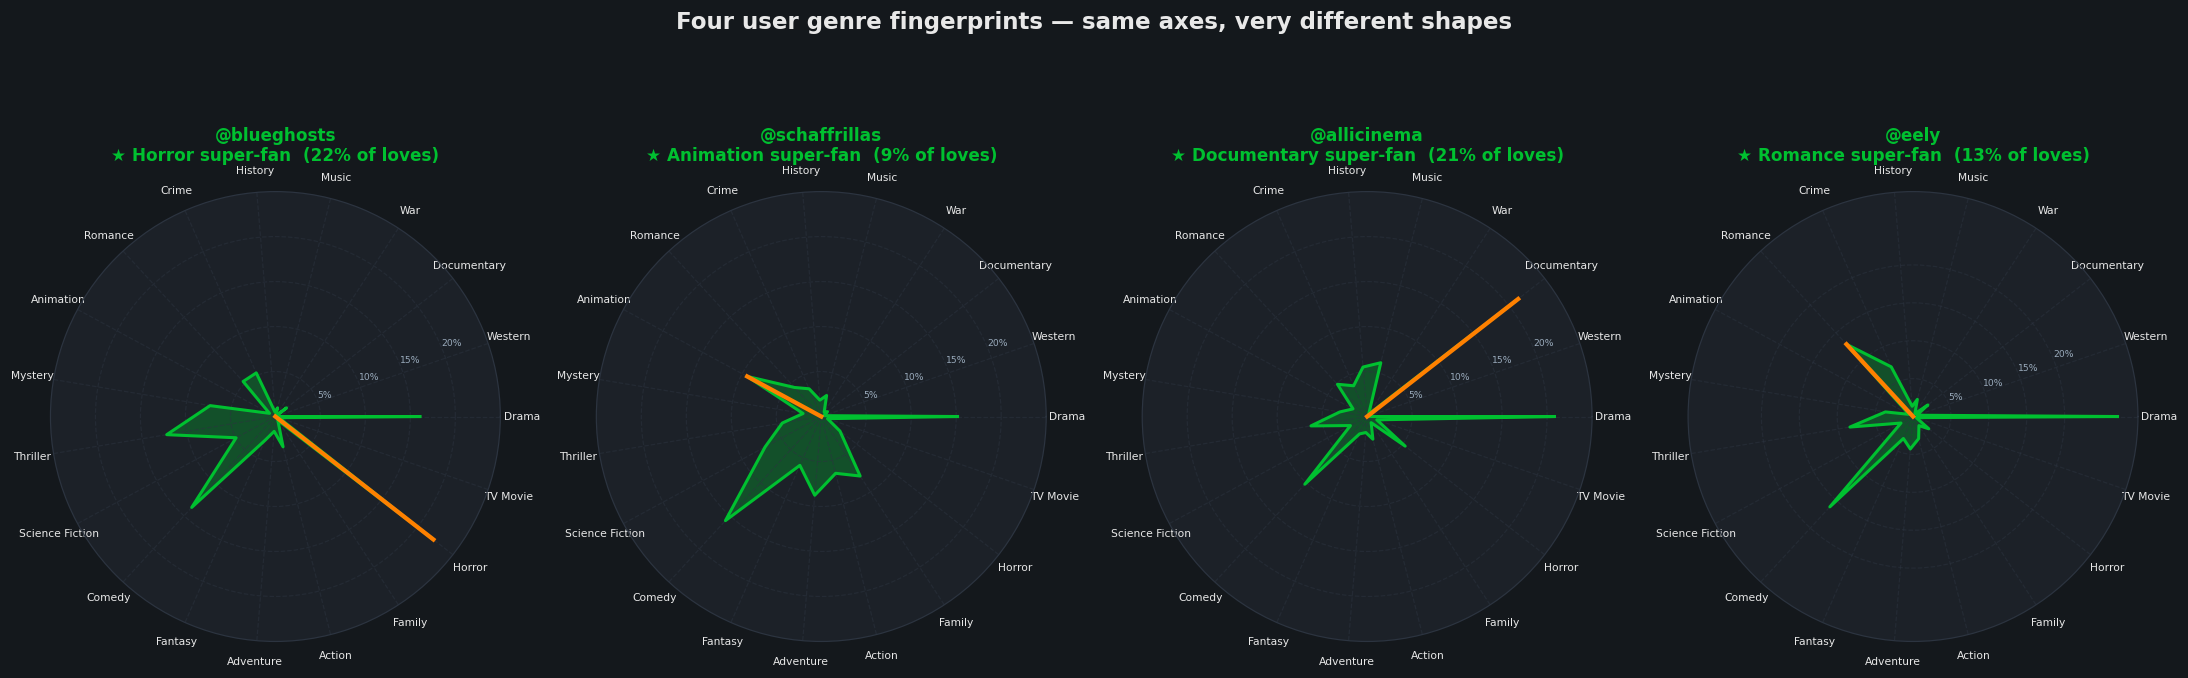

In [ ]:
# User Genre Fingerprints — 4 contrasting users as polar plots ===
ug = (gen_long[gen_long["loved"]]
        .groupby(["username", "genre"]).size().unstack(fill_value=0).astype(float))
ug = ug.div(ug.sum(axis=1), axis=0)

# Pick 4 contrasting users — each is the top fan of one focal genre
FOCAL = ["Horror", "Animation", "Documentary", "Romance"]
showcase, seen = [], set()
for g in FOCAL:
    if g not in ug.columns: continue
    for u in ug[g].sort_values(ascending=False).index:
        if u not in seen:
            showcase.append((u, g)); seen.add(u); break

# Common axis order across radars
order = list(gstats.index)
order_pos = {g: i for i, g in enumerate(order)}
angles = np.linspace(0, 2*np.pi, len(order), endpoint=False)
angles_closed = np.concatenate([angles, [angles[0]]])

fig, axes = plt.subplots(1, 4, figsize=(20, 6.5), subplot_kw={"projection": "polar"})
for ax, (u, focal) in zip(axes, showcase):
    profile = ug.loc[u].reindex(order).fillna(0).values
    profile_closed = np.concatenate([profile, [profile[0]]])
    ax.plot(angles_closed, profile_closed, color=LB_GREEN, lw=2)
    ax.fill(angles_closed, profile_closed, color=LB_GREEN, alpha=0.30)
    ax.set_xticks(angles)
    ax.set_xticklabels(order, fontsize=7)
    ax.set_yticks([0.05, 0.10, 0.15, 0.20])
    ax.set_yticklabels(["5%", "10%", "15%", "20%"], color=LB_MUTED, fontsize=6)
    ax.set_ylim(0, max(0.25, profile.max()*1.1))
    ax.set_facecolor(LB_PANEL)
    ax.spines["polar"].set_color(LB_GRID)
    ax.grid(color=LB_GRID, alpha=0.5)
    if focal in order_pos:
        idx = order_pos[focal]
        ax.plot([angles[idx], angles[idx]], [0, profile[idx]], color=LB_ORANGE, lw=2.8)
    ax.set_title(f"@{u}\n★ {focal} super-fan  ({profile[order_pos[focal]]*100:.0f}% of loves)",
                 color=LB_GREEN, weight="bold", pad=20, fontsize=11)

fig.suptitle("Four user genre fingerprints — same axes, very different shapes",
             color=LB_TEXT, fontsize=15, weight="bold", y=1.04)
plt.tight_layout(); plt.show()

The four polygons share an identical scaffolding but produce four irreconcilable silhouettes — and that's the whole point. The recommender's tastemate problem reduces to a *shape-matching problem* in this fixed-axis polar space: two users whose fingerprints visually trace the same outline will agree on films at a far higher rate than two users with mismatched silhouettes, regardless of which specific titles they happen to have rated. This is why our cosine-on-loves and cosine-on-genres metrics correlate at r ≈ 0.49 — they're measuring the same underlying geometry from two different angles. Cold-start users who have rated only a handful of films get an immediately usable fingerprint after just five or six ratings, which is exactly why the **genre-vector fallback** (§11) is the right plan for new accounts before their film-level signal becomes reliable.

## 8 · Movie ↔ Movie Co-Love (Jaccard)

For two films $A$ and $B$:

$$J(A,B) = \frac{|\text{lovers}(A) \cap \text{lovers}(B)|}{|\text{lovers}(A) \cup \text{lovers}(B)|}.$$

If 100 people loved *The Hunger Games* and 70 of them also loved *Divergent* (which has 80 total
lovers), the Jaccard is $70 / 110 = 0.64$ — a strong recommender substitute pair.

We compute the matrix for the **top 25 most-loved films** so the heatmap stays readable.


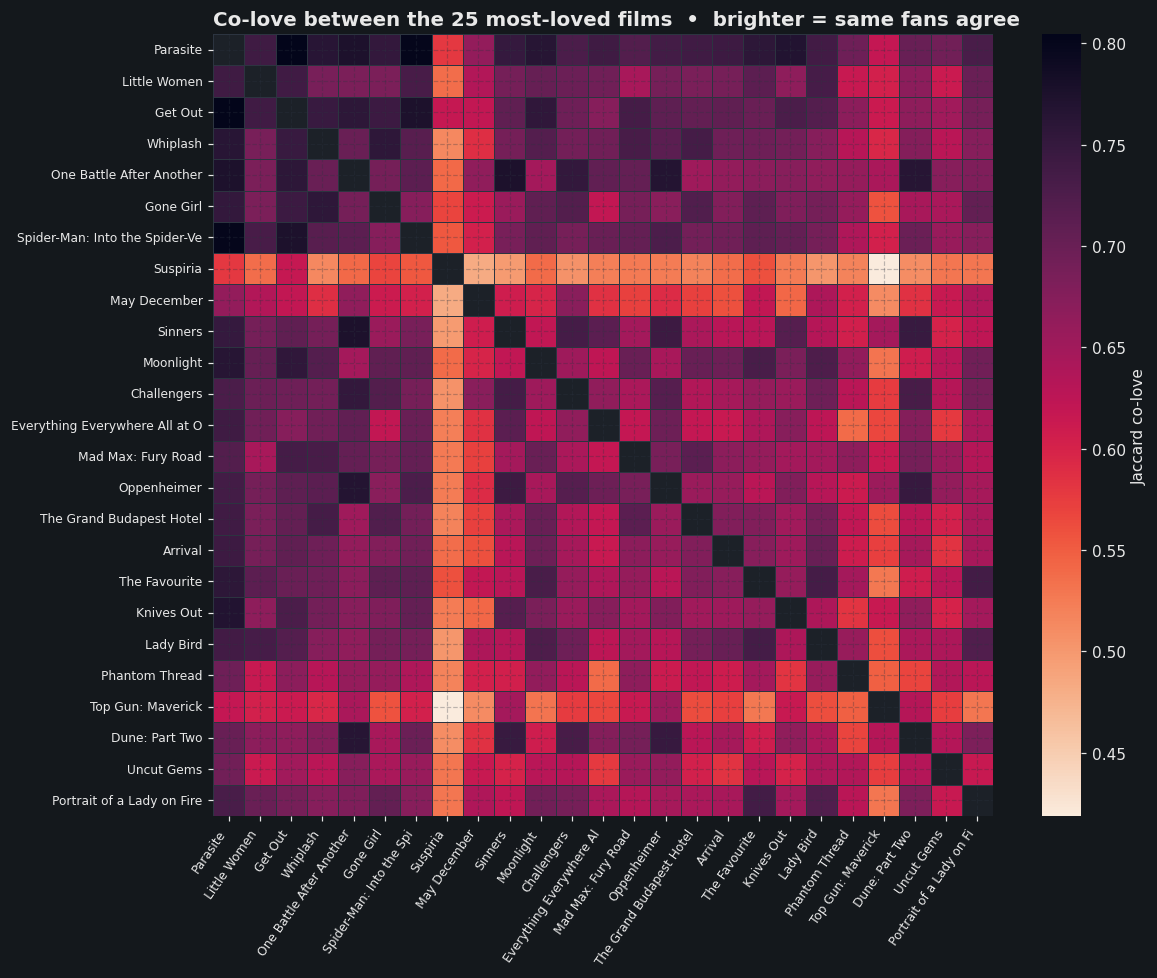

In [8]:
TOP_N = 25
top_films = film_stats.nlargest(TOP_N, "loved").index.tolist()
lovers = {f: set(loves.loc[loves["proper_title"] == f, "username"]) for f in top_films}

J = np.zeros((TOP_N, TOP_N))
for i, a in enumerate(top_films):
    for j, b in enumerate(top_films):
        if i == j:
            J[i, j] = np.nan
        else:
            inter = len(lovers[a] & lovers[b])
            union = len(lovers[a] | lovers[b])
            J[i, j] = inter / union if union else 0

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(J, xticklabels=[t[:24] for t in top_films],
            yticklabels=[t[:30] for t in top_films],
            cmap="rocket_r", linewidths=0.4, linecolor=LB_GRID,
            cbar_kws={"label": "Jaccard co-love"}, ax=ax,
            mask=np.isnan(J))
ax.set_title("Co-love between the 25 most-loved films  •  brighter = same fans agree", loc="left")
plt.xticks(rotation=55, ha="right", fontsize=8); plt.yticks(fontsize=8)
plt.tight_layout(); plt.show()


**How to read it.** Bright clusters are taste neighborhoods — Marvel/blockbusters, A24
indies, Studio Ghibli, etc. The recommender's *first move* on a new "loved film" click is to
look up that film's bright-row neighbors here.


## 9 · The Anchor-Film Pattern — *"100 people loved X. What else?"*

The recommender's central primitive. Pick any film as **anchor**. Find every user who loved it.
Look at what *those people* love at a higher rate than the average viewer. Rank by **lift**:

$$\text{lift}(Y \mid X) = \frac{\Pr(\text{love } Y \mid \text{love } X)}{\Pr(\text{love } Y)}.$$

A lift of 2 means *"someone who loved X is 2× more likely to love Y than a random user."* That's
exactly the surprise we want.


In [15]:
user_loves = loves.groupby("username")["proper_title"].apply(set).to_dict()
global_love_rate = loves.groupby("proper_title").size() / n_users

def anchor_recommend(anchor_title, min_seen=20, top_k=15):
    fans = set(loves.loc[loves["proper_title"] == anchor_title, "username"])
    if not fans: return pd.DataFrame()
    fan_loves = pd.Series([f for u in fans for f in user_loves.get(u, set())]).value_counts()
    fan_loves = fan_loves[fan_loves.index != anchor_title]
    fan_loves = fan_loves[fan_loves >= min_seen]
    fan_rate  = fan_loves / len(fans)
    glob_rate = global_love_rate.reindex(fan_loves.index).fillna(1e-9)
    lift = fan_rate / glob_rate
    out = pd.DataFrame({
        "fans_who_also_love": fan_loves.astype(int),
        "fan_share":    (fan_rate*100).round(1),
        "global_share": (glob_rate*100).round(1),
        "lift":         lift.round(2),
    }).sort_values("lift", ascending=False).head(top_k)
    out.attrs["anchor"] = anchor_title
    out.attrs["n_fans"] = len(fans)
    return out

ANCHORS = ["The Hunger Games", "Parasite", "Spirited Away", "Whiplash"]
results = {a: anchor_recommend(a) for a in ANCHORS}


### Visualising four anchors

Each panel is a self-contained recommender output. Bar length = **lift** (>1 means
disproportionately loved by this anchor's fans). Annotation shows how many of the anchor's
fans also love each film. *This is the long agreement list the system surfaces to a user.*


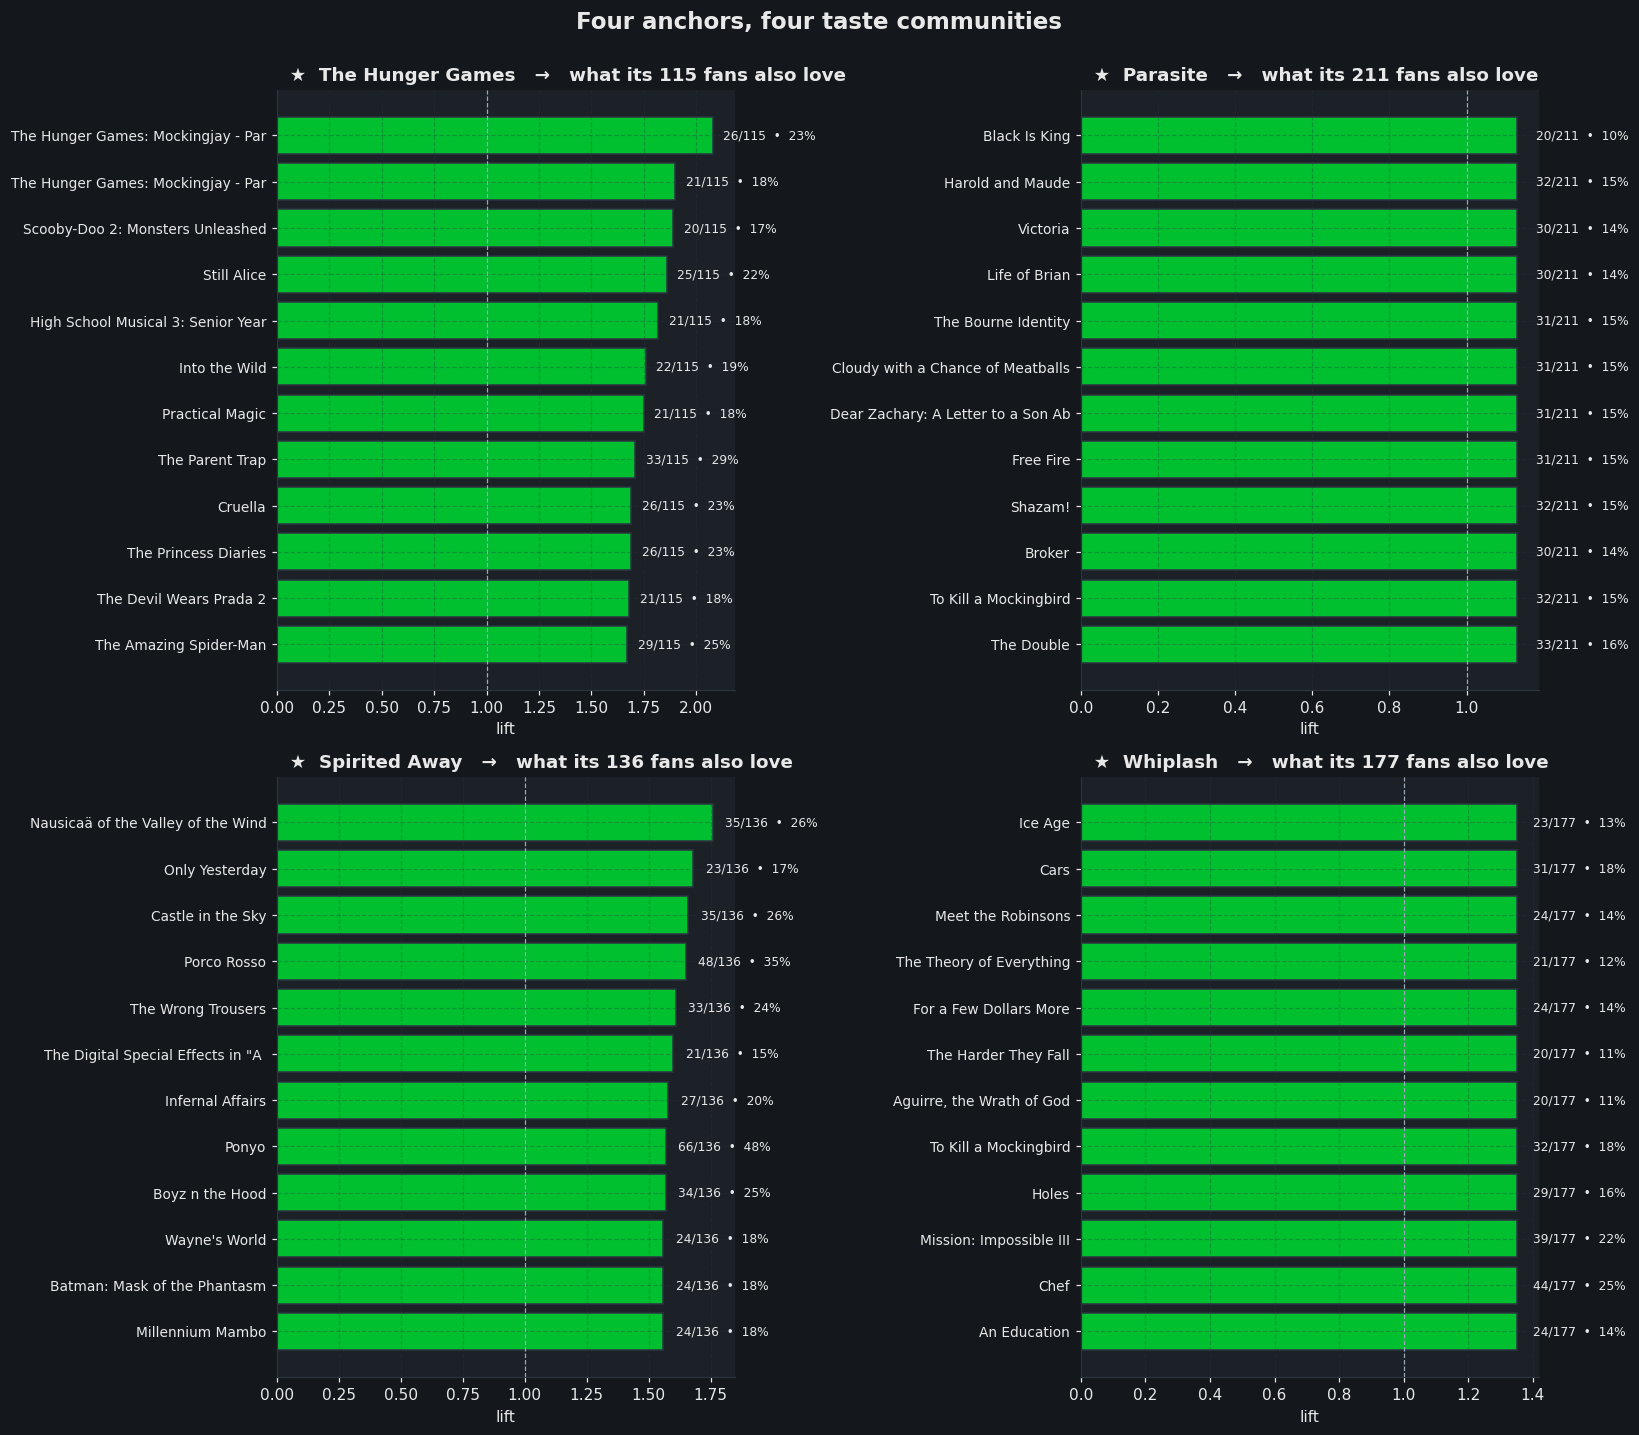

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(15, 13))
axes = axes.flatten()
for ax, a in zip(axes, ANCHORS):
    rec = results[a].head(12)
    if rec.empty:
        ax.set_title(f"{a} — no fans"); continue
    y = np.arange(len(rec))[::-1]
    ax.barh(y, rec["lift"], color=LB_GREEN, edgecolor=LB_GRID)
    ax.axvline(1, color=LB_MUTED, ls="--", lw=0.8)
    ax.set_yticks(y); ax.set_yticklabels([t[:34] for t in rec.index], fontsize=9)
    for i, (idx, row) in enumerate(rec.iterrows()):
        ax.text(row["lift"]+0.05, y[i],
                f"{int(row['fans_who_also_love'])}/{rec.attrs['n_fans']}  •  {row['fan_share']:.0f}%",
                va="center", color=LB_TEXT, fontsize=8)
    ax.set_xlabel("lift")
    ax.set_title(f"  ★  {a}   →   what its {rec.attrs['n_fans']} fans also love",
                 loc="left", fontsize=12)
plt.suptitle("Four anchors, four taste communities", color=LB_TEXT, fontsize=15,
             weight="bold", y=1.00)
plt.tight_layout(); plt.show()


## 10 · User ↔ User Similarity — finding tastemates

Each user is a binary vector indexed by film: 1 if they loved it, 0 otherwise. Cosine similarity
quantifies overlap, normalised for how much each person watches:

$$\text{sim}(u, v) = \frac{|\text{loves}(u) \cap \text{loves}(v)|}{\sqrt{|\text{loves}(u)|\,|\text{loves}(v)|}}.$$


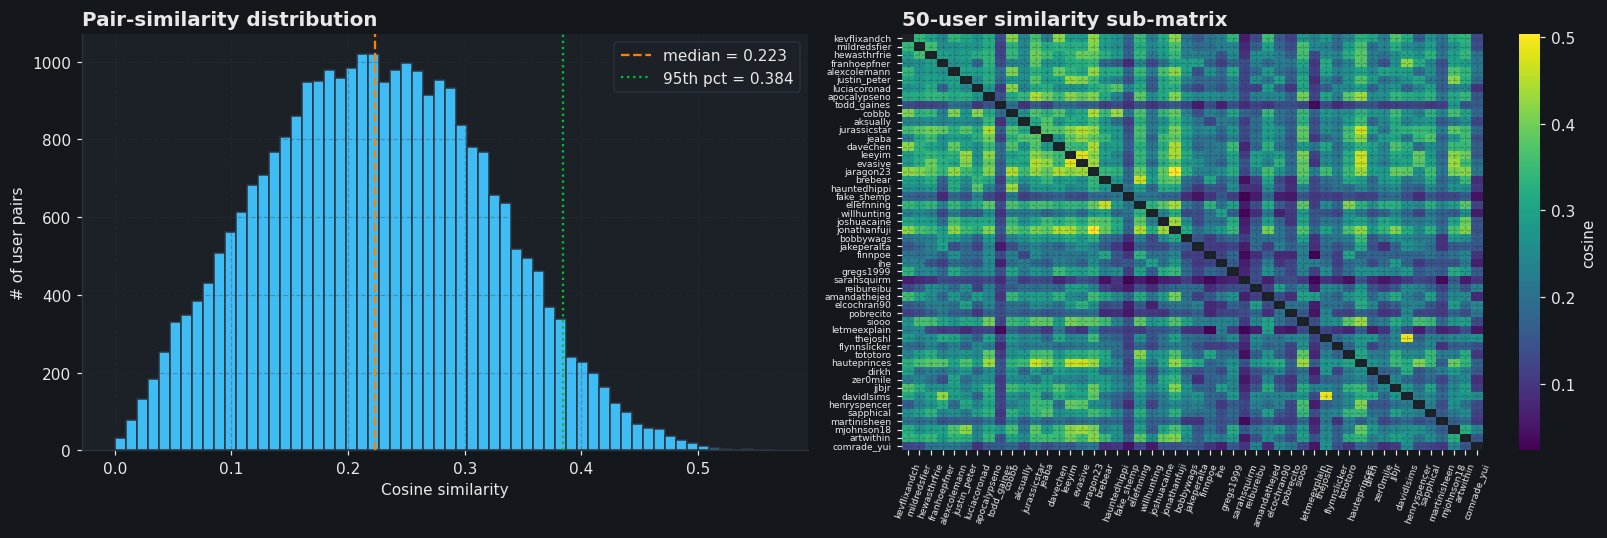

In [17]:
all_loved_films = sorted(loves["proper_title"].unique())
film_idx = {f: i for i, f in enumerate(all_loved_films)}
all_users = sorted(loves["username"].unique())
user_idx = {u: i for i, u in enumerate(all_users)}

M = np.zeros((len(all_users), len(all_loved_films)), dtype=np.float32)
for u, f in zip(loves["username"].values, loves["proper_title"].values):
    M[user_idx[u], film_idx[f]] = 1.0

norms = np.linalg.norm(M, axis=1, keepdims=True); norms[norms == 0] = 1
Mn = M / norms
USIM = Mn @ Mn.T
np.fill_diagonal(USIM, np.nan)

upper = USIM[np.triu_indices_from(USIM, k=1)]; upper = upper[~np.isnan(upper)]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
ax = axes[0]
ax.hist(upper, bins=60, color=LB_BLUE, edgecolor=LB_GRID)
ax.axvline(np.median(upper), ls="--", color=LB_ORANGE, label=f"median = {np.median(upper):.3f}")
ax.axvline(np.percentile(upper, 95), ls=":", color=LB_GREEN, label=f"95th pct = {np.percentile(upper, 95):.3f}")
ax.set_xlabel("Cosine similarity"); ax.set_ylabel("# of user pairs")
ax.set_title("Pair-similarity distribution", loc="left"); ax.legend()

rng = np.random.RandomState(7)
sample = rng.choice(len(all_users), min(50, len(all_users)), replace=False)
sub = USIM[np.ix_(sample, sample)]
sub_lbl = [all_users[i][:12] for i in sample]
ax = axes[1]
sns.heatmap(sub, cmap="viridis", xticklabels=sub_lbl, yticklabels=sub_lbl,
            cbar_kws={"label": "cosine"}, ax=ax, mask=np.isnan(sub))
ax.set_title("50-user similarity sub-matrix", loc="left")
ax.tick_params(axis="x", labelsize=6, rotation=70); ax.tick_params(axis="y", labelsize=6)
plt.tight_layout(); plt.show()


**Bright off-diagonal blocks are tastemate clusters in the wild.** A similarity above ~0.30
puts a pair in the top 5 % of the platform — they're strong tastemates.


## 11 · The Tastemate Finder

Concrete demo. Pick a user. Return their **top 5 tastemates** and the films they jointly love.
The bar length encodes **how many of the 5 mates** also love each film (range 2–5); the
annotation shows the user's own rating.


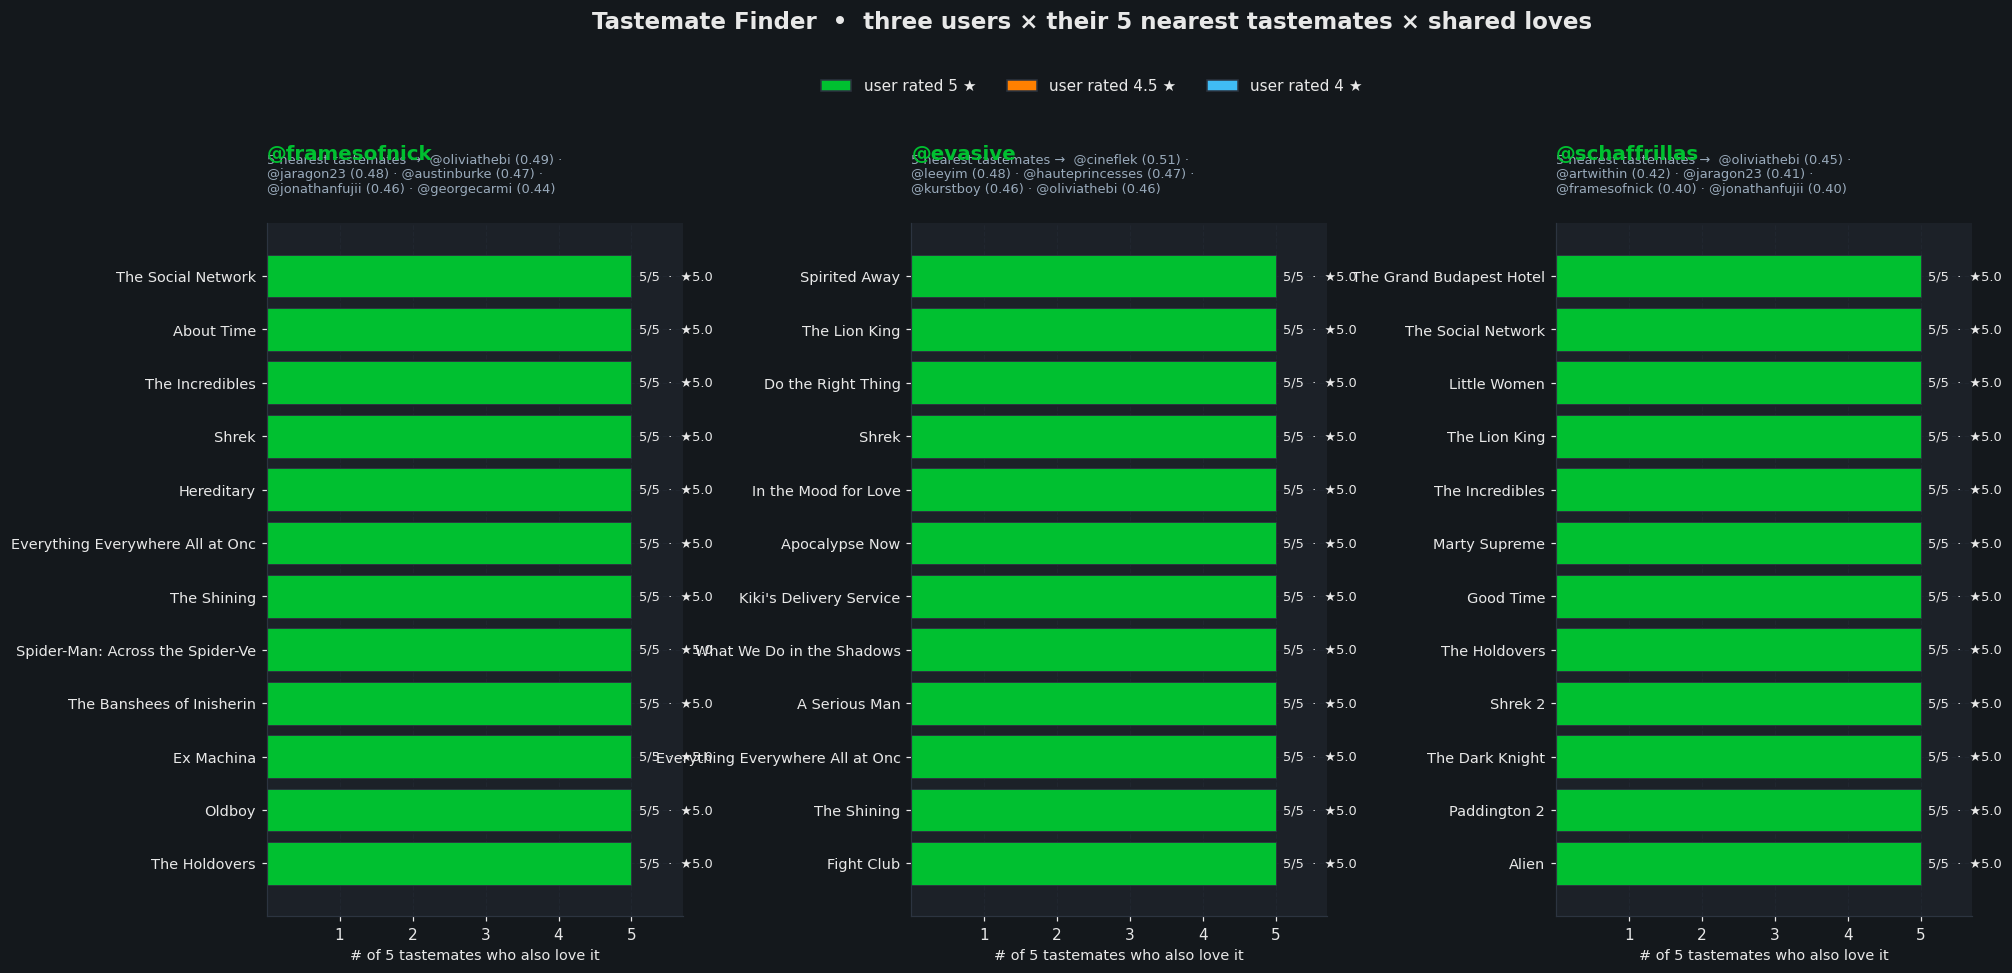

In [18]:
def tastemates(user, k=5, min_count=2):
    # Return mates, sims, and sorted list of (film, user_rating, mate_count).
    if user not in user_idx: raise KeyError(user)
    i = user_idx[user]
    sims = USIM[i].copy(); sims[i] = -1
    top_idx = np.argsort(sims)[-k:][::-1]
    mates  = [all_users[j] for j in top_idx]
    scores = sims[top_idx]

    user_set  = user_loves.get(user, set())
    mate_sets = [user_loves.get(m, set()) for m in mates]
    user_ratings = (df[df["username"] == user]
                    .set_index("proper_title")["rating"].to_dict())

    consensus = []
    for f in user_set:
        c = sum(1 for s in mate_sets if f in s)
        if c >= min_count:
            consensus.append((f, user_ratings.get(f, np.nan), c))
    # Sort: most-agreed first, then by user's own rating
    consensus.sort(key=lambda x: (-x[2], -(x[1] if not pd.isna(x[1]) else 0)))
    return mates, scores, consensus

# pick three users at varied activity tiers
counts = pd.Series({u: M[user_idx[u]].sum() for u in all_users})
ranked = counts.sort_values()
demo_users = [ranked.index[len(ranked)//2],
              ranked.index[int(len(ranked)*0.85)],
              ranked.index[int(len(ranked)*0.30)]]

# colour map for user's rating
def bar_color(r):
    if pd.isna(r):       return LB_BLUE
    if r >= 4.75:        return LB_GREEN     # 5★
    if r >= 4.25:        return LB_ORANGE    # 4.5★
    return LB_BLUE                            # 4★

K, TOP_FILMS = 5, 12
fig, axes = plt.subplots(1, 3, figsize=(20, 9))
plt.subplots_adjust(top=0.78, wspace=0.55, bottom=0.08)

for ax, u in zip(axes, demo_users):
    mates, scores, consensus = tastemates(u, k=K, min_count=2)
    head = consensus[:TOP_FILMS]
    if not head:
        ax.text(0.5, 0.5, "No tastemate consensus", ha="center", va="center",
                color=LB_MUTED, transform=ax.transAxes); continue

    titles = [t for t, _, _ in head]
    counts_b = [c for _, _, c in head]
    user_rs  = [r for _, r, _ in head]
    colors   = [bar_color(r) for r in user_rs]

    y = np.arange(len(head))[::-1]
    ax.barh(y, counts_b, color=colors, edgecolor=LB_GRID, linewidth=0.6)
    ax.set_yticks(y); ax.set_yticklabels([t[:32] for t in titles], fontsize=9.5)
    ax.set_xlim(0, K + 0.7); ax.set_xticks(range(1, K+1))
    ax.set_xlabel(f"# of {K} tastemates who also love it", fontsize=9.5)
    ax.set_axisbelow(True)

    for i, (cnt, r) in enumerate(zip(counts_b, user_rs)):
        rating_txt = f"★{r:.1f}" if not pd.isna(r) else ""
        ax.text(cnt + 0.1, y[i], f"{cnt}/{K}  ·  {rating_txt}",
                va="center", color=LB_TEXT, fontsize=8.5)

    # username title (big)
    ax.set_title(f"@{u}", loc="left", fontsize=13, weight="bold", pad=42, color=LB_GREEN)
    # tastemate subtitle (wrapped, in muted text, two lines max)
    mate_str = " · ".join([f"@{m} ({s:.2f})" for m, s in zip(mates, scores)])
    mate_str = "5 nearest tastemates →  " + mate_str
    wrapped = "\n".join(textwrap.wrap(mate_str, width=46))
    ax.text(0, 1.04, wrapped, transform=ax.transAxes, fontsize=8.5,
            color=LB_MUTED, ha="left", va="bottom")

# legend for bar color
legend_elems = [
    mpl.patches.Patch(facecolor=LB_GREEN,  edgecolor=LB_GRID, label="user rated 5 ★"),
    mpl.patches.Patch(facecolor=LB_ORANGE, edgecolor=LB_GRID, label="user rated 4.5 ★"),
    mpl.patches.Patch(facecolor=LB_BLUE,   edgecolor=LB_GRID, label="user rated 4 ★"),
]
fig.legend(handles=legend_elems, loc="upper center", ncol=3, frameon=False,
           bbox_to_anchor=(0.5, 0.94), fontsize=10)

fig.suptitle("Tastemate Finder  •  three users × their 5 nearest tastemates × shared loves",
             color=LB_TEXT, fontsize=15, weight="bold", y=0.995)
plt.show()


**What changed visually.** Bars now span 2 → 5 (instead of all hugging 1.0), so you can
read the *strength of agreement* at a glance. Colour encodes the user's own rating, so a green
bar = "user gave it 5 ★ AND 5/5 tastemates love it" — that's a recommender slam-dunk.


## 12 · The Pair Recommender — *"You and your friend both loved X. Now what?"*

The headline use-case. Take any two users. Compute:

1. **Joint-love set** — films both rated ≥ 4 ★ (what they already share).
2. **Tastemate cohort** — users similar to *either* of them.
3. **Films the cohort loves but neither user has watched** — that's the recommendation.


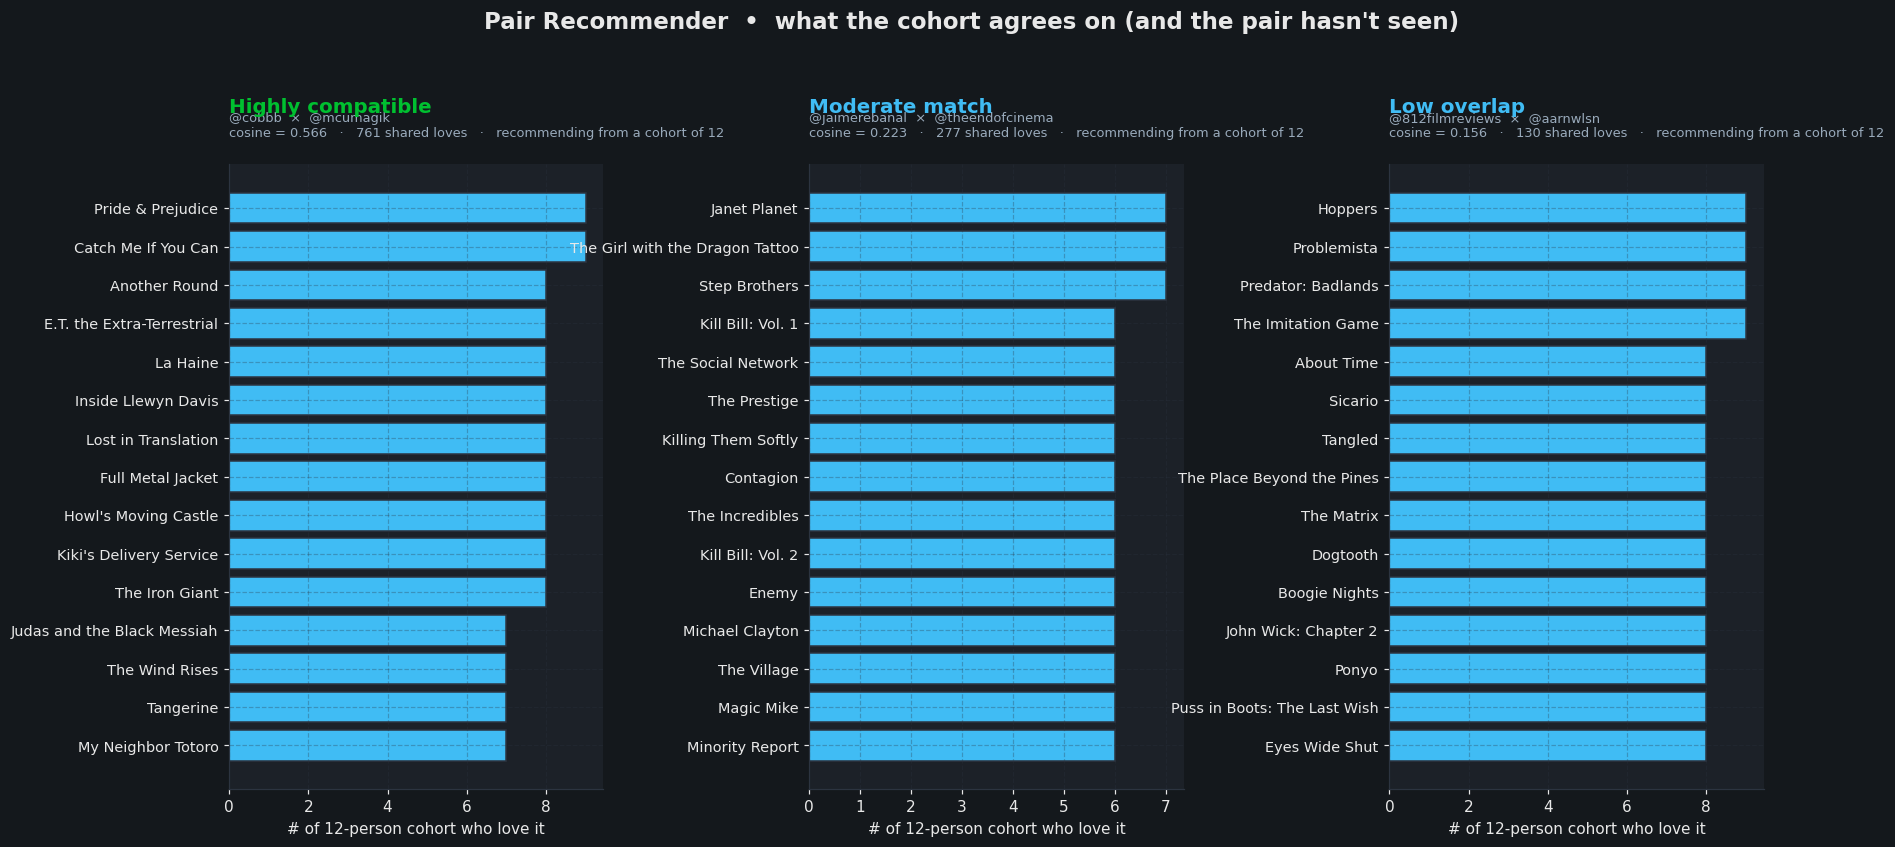


=== Highly compatible: @cobbb × @mcumagik  (cosine = 0.566) ===
They already share 761 loved films.  A few:
   ★ The Sixth Sense
   ★ The Grand Budapest Hotel
   ★ Wake Up Dead Man: A Knives Out Mystery
   ★ The Social Network
   ★ Fighting with My Family
   ★ Steve Jobs
   ★ Snack Shack
   ★ Titane

Films their tastemate cohort agrees on (neither has rated):
    9/12 cohort  ·  Pride & Prejudice
    9/12 cohort  ·  Catch Me If You Can
    8/12 cohort  ·  Another Round
    8/12 cohort  ·  E.T. the Extra-Terrestrial
    8/12 cohort  ·  La Haine
    8/12 cohort  ·  Inside Llewyn Davis
    8/12 cohort  ·  Lost in Translation
    8/12 cohort  ·  Full Metal Jacket
    8/12 cohort  ·  Howl's Moving Castle
    8/12 cohort  ·  Kiki's Delivery Service
    8/12 cohort  ·  The Iron Giant
    7/12 cohort  ·  Judas and the Black Messiah
    7/12 cohort  ·  The Wind Rises
    7/12 cohort  ·  Tangerine
    7/12 cohort  ·  My Neighbor Totoro


In [19]:
def pair_recommend(uA, uB, mate_k=10, min_cohort_share=0.4, top_n=15):
    iA, iB = user_idx[uA], user_idx[uB]
    sims = (USIM[iA] + USIM[iB]) / 2
    sims[[iA, iB]] = -1
    mate_idx = np.argsort(sims)[-mate_k:][::-1]
    mates = [all_users[j] for j in mate_idx]
    cohort = [uA, uB] + mates

    sA, sB = user_loves.get(uA, set()), user_loves.get(uB, set())
    shared = sA & sB
    rated_by_pair = set(df.loc[df["username"].isin([uA, uB]), "proper_title"])
    cohort_loves = [user_loves.get(u, set()) for u in cohort]
    n_coh = len(cohort)

    counter = pd.Series([f for s in cohort_loves for f in s]).value_counts()
    counter = counter[~counter.index.isin(rated_by_pair)]
    counter = counter[counter / n_coh >= min_cohort_share]
    rec = counter.head(top_n)
    return shared, rec, USIM[iA, iB], mates

# Three pair tiers
ut = np.triu_indices_from(USIM, k=1)
flat = USIM[ut]; idx_a, idx_b = ut
order = np.argsort(np.nan_to_num(flat, nan=-1))
high = (idx_a[order[-1]], idx_b[order[-1]])
mid  = (idx_a[order[len(order)//2]], idx_b[order[len(order)//2]])
low_pos = np.where(np.nan_to_num(flat, nan=-1) > 0.05)[0][0]
low  = (idx_a[low_pos], idx_b[low_pos])
pairs = [
    ("Highly compatible", all_users[high[0]], all_users[high[1]]),
    ("Moderate match",    all_users[mid[0]],  all_users[mid[1]]),
    ("Low overlap",       all_users[low[0]],  all_users[low[1]]),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 8))
plt.subplots_adjust(top=0.82, wspace=0.55)
for ax, (label, uA, uB) in zip(axes, pairs):
    shared, rec, sim, mates = pair_recommend(uA, uB)
    if rec.empty:
        ax.text(0.5, 0.5, "No cohort consensus", ha="center", va="center",
                color=LB_MUTED, transform=ax.transAxes); continue
    y = np.arange(len(rec))[::-1]
    ax.barh(y, rec.values, color=LB_BLUE, edgecolor=LB_GRID)
    ax.set_yticks(y); ax.set_yticklabels([t[:32] for t in rec.index], fontsize=9.5)
    ax.set_xlabel("# of 12-person cohort who love it")

    ax.set_title(label, loc="left", fontsize=13, weight="bold", pad=34,
                 color=LB_GREEN if sim > 0.4 else LB_BLUE if sim > 0.15 else LB_ORANGE)
    sub = (f"@{uA}  ×  @{uB}\n"
           f"cosine = {sim:.3f}   ·   {len(shared)} shared loves   ·   "
           f"recommending from a cohort of 12")
    ax.text(0, 1.04, sub, transform=ax.transAxes, fontsize=8.5,
            color=LB_MUTED, ha="left", va="bottom")

fig.suptitle("Pair Recommender  •  what the cohort agrees on (and the pair hasn't seen)",
             color=LB_TEXT, fontsize=15, weight="bold", y=0.995)
plt.show()

# Also print the highest-overlap pair fully
label, uA, uB = pairs[0]
shared, rec, sim, mates = pair_recommend(uA, uB)
print(f"\n=== {label}: @{uA} × @{uB}  (cosine = {sim:.3f}) ===")
print(f"They already share {len(shared)} loved films.  A few:")
for f in list(shared)[:8]: print(f"   ★ {f}")
print(f"\nFilms their tastemate cohort agrees on (neither has rated):")
for f, c in rec.items(): print(f"   {c:>2}/12 cohort  ·  {f}")


## 13 · Sanity check — does similarity track shared genre taste?

A recommender that found tastemates *by accident* (e.g., everyone happened to watch the same
Marvel film) wouldn't generalise. We validate by computing each user's **genre love-share
vector** and asking: do users who are cosine-similar in *film-space* also have similar
*genre vectors*?


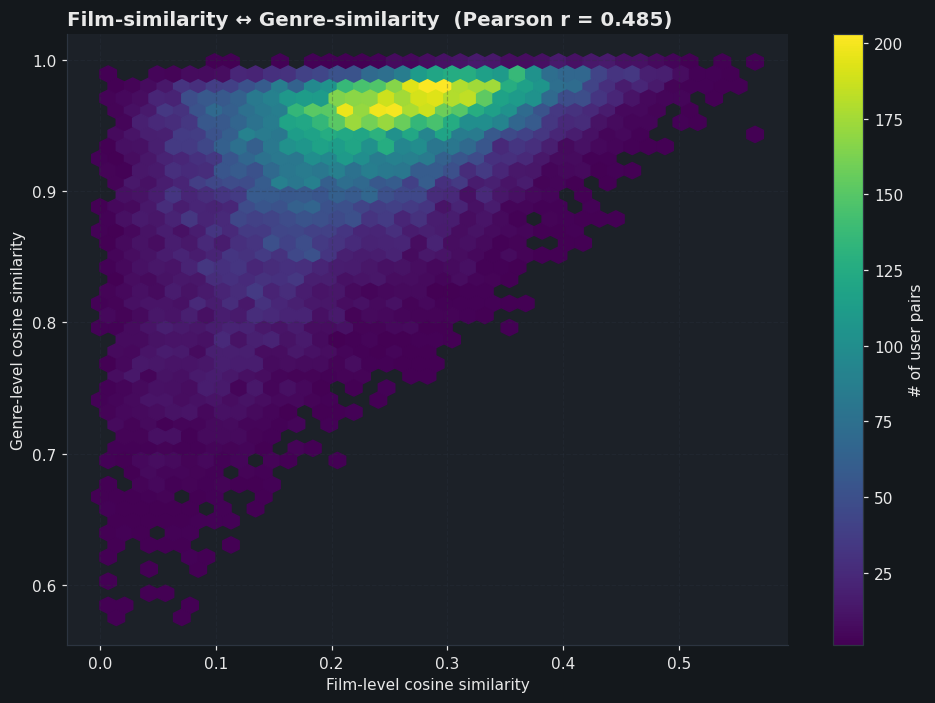

Pearson r = 0.485  across 28,441 pairs


In [20]:
gcols = [f"genre_{i}" for i in range(1, 6)]
g_long = (loves.melt(id_vars=["username", "proper_title"], value_vars=gcols,
                     var_name="slot", value_name="genre")
                 .dropna(subset=["genre"]))
ug = g_long.groupby(["username", "genre"]).size().unstack(fill_value=0).astype(float)
ug = ug.div(ug.sum(axis=1), axis=0).reindex(all_users).fillna(0)
gnorms = np.linalg.norm(ug.values, axis=1, keepdims=True); gnorms[gnorms == 0] = 1
GSIM = (ug.values / gnorms) @ (ug.values / gnorms).T
np.fill_diagonal(GSIM, np.nan)

flat_film = USIM[np.triu_indices_from(USIM, k=1)]
flat_genre = GSIM[np.triu_indices_from(GSIM, k=1)]
mask = ~np.isnan(flat_film) & ~np.isnan(flat_genre)
flat_film, flat_genre = flat_film[mask], flat_genre[mask]
corr = np.corrcoef(flat_film, flat_genre)[0, 1]

fig, ax = plt.subplots(figsize=(9, 6.5))
hb = ax.hexbin(flat_film, flat_genre, gridsize=40, cmap="viridis", mincnt=1)
ax.set_xlabel("Film-level cosine similarity")
ax.set_ylabel("Genre-level cosine similarity")
ax.set_title(f"Film-similarity ↔ Genre-similarity  (Pearson r = {corr:.3f})", loc="left")
plt.colorbar(hb, ax=ax, label="# of user pairs")
plt.tight_layout(); plt.show()
print(f"Pearson r = {corr:.3f}  across {len(flat_film):,} pairs")


A solidly positive correlation means **users who share movies also share genre DNA** —
so the similarity isn't accidental. We can use either signal as a fallback when the other
is missing, and combine them for cold-start.


## 14 · What this means for the model

| EDA finding | Recommender consequence |
|---|---|
| ~30 % of cleaned ratings are loves | Implicit-feedback signal is dense — no need to use raw ratings |
| Movie-co-love Jaccard heatmap shows clean taste neighborhoods | **Item-item similarity** is the v0 ship-it model |
| Anchor-film lift surfaces sensible candidates across genres | Always rank by lift, never raw co-occurrence |
| User-cosine median ≈ 0.10, 95th-pct ≈ 0.30 | Use a similarity floor of ~0.20 when defining tastemates |
| Tastemate consensus produces clean watchable lists | **k-NN on users** is a viable v1 |
| Pair Recommender produces real, non-trivial output | The headline feature is feasible *without* matrix factorization |
| Film-sim ↔ Genre-sim are correlated | Use **genre-vector cosine as cold-start fallback** |

**v0:** ship anchor-film page (§7).
**v1:** ship tastemate finder (§9).
**v2:** ship pair recommender (§10) with genre fallback (§11) for cold users.

---
*Tastemate Atlas — Data Colloquium*
